In [1]:
import scipy.integrate

import json
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import healpy as hp
import astropy
import os
import pickle
import scipy.linalg as LA
import h5py
import py3nj
import pyne2001

import pymaster as nmt
import matplotlib.colors as mcolors

In [2]:
nbins = 10

frb_path = [f"cat2_dm_bin_{nbins}_{i}.h5" for i in range(nbins)]

gal_path = ["/lustre06/project/6034496/hcwang96/dmxgal/checks/2_Galaxy_catalog/DESI_LIS/DR8/north/DESI_LIS_BGS_north_z_0.05_0.1.h5", 
            "/lustre06/project/6034496/hcwang96/dmxgal/checks/2_Galaxy_catalog/DESI_LIS/DR8/north/DESI_LIS_BGS_north_z_0.1_0.2.h5",
            "/lustre06/project/6034496/hcwang96/dmxgal/checks/2_Galaxy_catalog/DESI_LIS/DR8/north/DESI_LIS_BGS_north_z_0.2_0.3.h5",
            "/lustre06/project/6034496/hcwang96/dmxgal/checks/2_Galaxy_catalog/DESI_LIS/DR8/north/DESI_LIS_BGS_north_z_0.3_0.4.h5",
            "/lustre06/project/6034496/hcwang96/dmxgal/checks/2_Galaxy_catalog/DESI_LIS/DR8/north/DESI_LIS_BGS_north_z_0.4_0.5.h5"]
gal_ran_path = ["/lustre06/project/6034496/hcwang96/dmxgal/checks/2_Galaxy_catalog/DESI_LIS/DR8/north/DESI_LIS_BGS_north_ran_all_z_v2.h5",
                "/lustre06/project/6034496/hcwang96/dmxgal/checks/2_Galaxy_catalog/DESI_LIS/DR8/north/DESI_LIS_BGS_north_ran_all_z_v2.h5",
                "/lustre06/project/6034496/hcwang96/dmxgal/checks/2_Galaxy_catalog/DESI_LIS/DR8/north/DESI_LIS_BGS_north_ran_all_z_v2.h5",
                "/lustre06/project/6034496/hcwang96/dmxgal/checks/2_Galaxy_catalog/DESI_LIS/DR8/north/DESI_LIS_BGS_north_ran_all_z_v2.h5",
                "/lustre06/project/6034496/hcwang96/dmxgal/checks/2_Galaxy_catalog/DESI_LIS/DR8/north/DESI_LIS_BGS_north_ran_all_z_v2.h5"]

In [3]:
class frbxgal:
    def __init__(self, frb_path, gal_path, gal_ran_path, bin_edges = [1, 10, 20, 30, 40, 67, 115, 196, 333, 565, 960, 1632, 2772], lmax = 2771):
        self.frb_path = frb_path
        self.gal_path = gal_path
        self.gal_ran_path = gal_ran_path
        assert len(self.gal_path) == len(self.gal_ran_path)
        self.n_dm_b = len(self.frb_path)
        self.n_z_b = len(self.gal_path)
        
        self.bin_edges = bin_edges
        self.lmax = lmax
        if self.bin_edges[-1] != self.lmax+1:
            self.bin_edges[-1] = self.lmax+1
        self.bin = nmt.NmtBin.from_edges(self.bin_edges[:-1], self.bin_edges[1:])
        self.leff = self.bin.get_effective_ells()
        self.bin_num = len(self.leff)

        self.ps = self.measure_ps()

    def read_frb_cat(self, path, name):
        assert name == 'cat2' or name == 'ran1' or name == 'ran2'
        file = h5py.File(path, 'r')
        l_deg = file[f"{name}_l"][:]
        b_deg = file[f"{name}_b"][:]
        w = np.ones_like(l_deg)
        return [l_deg, b_deg], w

    def read_frb_mock(self, path, name):
        assert name == 'cat2' or name == 'ran1' or name == 'ran2'
        file = h5py.File(path, 'r')
        l_deg = file[f"{name}_l"][:]
        b_deg = file[f"{name}_b"][:]
        return l_deg, b_deg
    
    def read_gal_cat(self, path):
        file = h5py.File(path, 'r')
        l_deg = file["l_deg"][:]
        b_deg = file["b_deg"][:]
        try: 
            w = file['w'][:]
        except KeyError:
            w = np.ones_like(l_deg)
        return [l_deg, b_deg], w

    def measure_ps(self):

        ps = np.zeros((self.n_z_b, self.n_dm_b, self.bin_num))
        self.gal_clus_save = []

        for zi, (gal_name, gran_name) in enumerate(zip(self.gal_path, self.gal_ran_path)):

            gal_pos, gal_w = self.read_gal_cat(gal_name)
            gran_pos, gran_w = self.read_gal_cat(gran_name)

            gal_clus = nmt.NmtFieldCatalogClustering(gal_pos, gal_w, gran_pos, gran_w, lmax=self.lmax, lonlat=True)
            self.gal_clus_save.append(gal_clus)

            for di, frb_name in enumerate(self.frb_path):

                print(f"Estimating power spectrum for redshift bin {zi} and DM bin {di}.")

                frb_pos, frb_w = self.read_frb_cat(frb_name, 'cat2')
                fran_pos, fran_w = self.read_frb_cat(frb_name, 'ran1')

                frb_clus = nmt.NmtFieldCatalogClustering(frb_pos, frb_w, fran_pos, fran_w, lmax=self.lmax, lonlat=True)
                w = nmt.NmtWorkspace.from_fields(frb_clus, gal_clus, self.bin)
                pcl = nmt.compute_coupled_cell(frb_clus, gal_clus)
                cl = w.decouple_cell(pcl)
                ps[zi, di, :] = cl[0,:]

        return ps

    def null_test(self, nsample):
        self.nsample = nsample
        self.rand_ps = np.zeros((self.n_z_b, self.n_dm_b, self.bin_num, self.nsample))
        
        for zi in range(self.n_z_b):

            gal_clus = self.gal_clus_save[zi]

            for di, frb_name in enumerate(self.frb_path):

                frb_pos, frb_w = self.read_frb_cat(frb_name, 'cat2')
                nfrb = len(frb_w)
                fran_pos, fran_w = self.read_frb_cat(frb_name, 'ran1')
                mock_l, mock_b = self.read_frb_mock(frb_name, 'ran2')
                nmock = len(mock_l)

                print(f"Estimating error bar for redshift bin {zi} and DM bin {di}.")
        
                for i in range(self.nsample):
                    
                    if i%100 == 0: print(i)

                    selection = np.random.choice(np.arange(nmock), size=nfrb, replace=False)
                    mock_pos = [mock_l[selection], mock_b[selection]]
                    mock_w = frb_w
                    
                    frb_mock_clus = nmt.NmtFieldCatalogClustering(mock_pos, mock_w, fran_pos, fran_w, lmax=self.lmax, lonlat=True)
                    w_err = nmt.NmtWorkspace.from_fields(frb_mock_clus, gal_clus, self.bin)
                    pcl_err = nmt.compute_coupled_cell(frb_mock_clus, gal_clus)
                    cl_err = w_err.decouple_cell(pcl_err)

                    self.rand_ps[zi, di, :, i] = cl_err[0][:]

        self.null_ps_mean = np.mean(self.rand_ps, axis=-1)
        self.error_bar = np.std(self.rand_ps, axis=-1)
        self.null_ps_mean_error = self.error_bar/np.sqrt(self.nsample) # standard deviation of the mean
    
    def plot_cl(self, figsize = (20, 5), exclude = False, style = 'lcl'):

        if exclude == True:
            bin_start = 4
        else:
            bin_start = 0
        
        fig, axes = plt.subplots(self.n_z_b, self.n_dm_b, sharey=True, figsize = figsize)
        axes = np.atleast_2d(axes)
        
        for zi in range(self.n_z_b):
            for di in range(self.n_dm_b):
            
                if style == 'lcl':
                
                    axes[zi, di].plot(self.leff[bin_start:], self.leff[bin_start:]*self.ps[zi, di, bin_start:], label = f'z bin {zi}, DM bin {di}', linestyle = 'dotted', marker=".")
                    axes[zi, di].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                    axes[zi, di].set_xscale("log")
                    axes[zi, di].set_xlabel(r'$\ell$', fontsize=15)
                    axes[zi, di].set_ylabel(r'$\ell C_\ell$', fontsize=15)
                    axes[zi, di].legend()

    def plot_null_ps(self, figsize = (20, 5), exclude = False, style = 'lcl'):

        if exclude == True:
            bin_start = 4
        else:
            bin_start = 0
    
        fig, axes = plt.subplots(self.n_z_b, self.n_dm_b, sharey=True, figsize = figsize)
        axes = np.atleast_2d(axes)

        for zi in range(self.n_z_b):
            for di in range(self.n_dm_b):
            
                if style == 'lcl':
        
                    axes[zi, di].errorbar(self.leff[bin_start:], self.leff[bin_start:]*self.null_ps_mean[zi, di, bin_start:], yerr=self.leff[bin_start:]*self.null_ps_mean_error[zi, di, bin_start:], capsize=2, marker=".",
                                     label = f'z bin {zi}, DM bin {di}', linestyle = 'none')
                    axes[zi, di].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                    axes[zi, di].set_xscale("log")
                    axes[zi, di].set_xlabel(r'$\ell$', fontsize=15)
                    axes[zi, di].set_ylabel(r'$\ell C_\ell$', fontsize=15)
                    axes[zi, di].legend()

    def plot_cl_err(self, figsize = (20, 5), exclude = False, style = 'lcl'):

        if exclude == True:
            bin_start = 4
        else:
            bin_start = 0
    
        fig, axes = plt.subplots(self.n_z_b, self.n_dm_b, sharey=True, figsize = figsize)
        axes = np.atleast_2d(axes)

        for zi in range(self.n_z_b):
            for di in range(self.n_dm_b):
            
                if style == 'lcl':
        
                    axes[zi, di].errorbar(self.leff[bin_start:], self.leff[bin_start:]*self.ps[zi, di, bin_start:], yerr=self.leff[bin_start:]*self.error_bar[zi, di, bin_start:], capsize=2, marker=".",
                                     label = f'z bin {zi}, DM bin {di}', linestyle = 'none')
                    axes[zi, di].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                    axes[zi, di].set_xscale("log")
                    axes[zi, di].set_xlabel(r'$\ell$', fontsize=15)
                    axes[zi, di].set_ylabel(r'$\ell C_\ell$', fontsize=15)
                    axes[zi, di].legend()
    
    def save(self, notes =''):

        outname = f"frbxgal_lmax{self.lmax}_{self.bin_num}_lb_{self.n_z_b}_zb_{self.n_dm_b}_db_{self.nsample}_samples{notes}.h5"
        file = h5py.File(outname, 'w')
        file.create_dataset('lmax', data = self.lmax)
        file.create_dataset('bin_edges', data = self.bin_edges)
        file.create_dataset('bin_centers', data = self.leff)
        file.create_dataset('n_z_b', data = self.n_z_b)
        file.create_dataset('n_dm_b', data = self.n_dm_b)
        file.create_dataset('cl', data = self.ps)
        file.create_dataset('error', data = self.error_bar)
        file.create_dataset('null_cl_mean', data = self.null_ps_mean)
        file.create_dataset('null_cl_error', data = self.null_ps_mean_error)
        file.close()

In [4]:
fg = frbxgal(frb_path, gal_path, gal_ran_path, bin_edges = [1, 10, 20, 30, 40, 67, 115, 196, 333, 565, 960, 1632, 2772], lmax = 2771)

Estimating power spectrum for redshift bin 0 and DM bin 0.
Estimating power spectrum for redshift bin 0 and DM bin 1.
Estimating power spectrum for redshift bin 0 and DM bin 2.
Estimating power spectrum for redshift bin 0 and DM bin 3.
Estimating power spectrum for redshift bin 0 and DM bin 4.
Estimating power spectrum for redshift bin 0 and DM bin 5.
Estimating power spectrum for redshift bin 0 and DM bin 6.
Estimating power spectrum for redshift bin 0 and DM bin 7.
Estimating power spectrum for redshift bin 0 and DM bin 8.
Estimating power spectrum for redshift bin 0 and DM bin 9.
Estimating power spectrum for redshift bin 1 and DM bin 0.
Estimating power spectrum for redshift bin 1 and DM bin 1.
Estimating power spectrum for redshift bin 1 and DM bin 2.
Estimating power spectrum for redshift bin 1 and DM bin 3.
Estimating power spectrum for redshift bin 1 and DM bin 4.
Estimating power spectrum for redshift bin 1 and DM bin 5.
Estimating power spectrum for redshift bin 1 and DM bin 

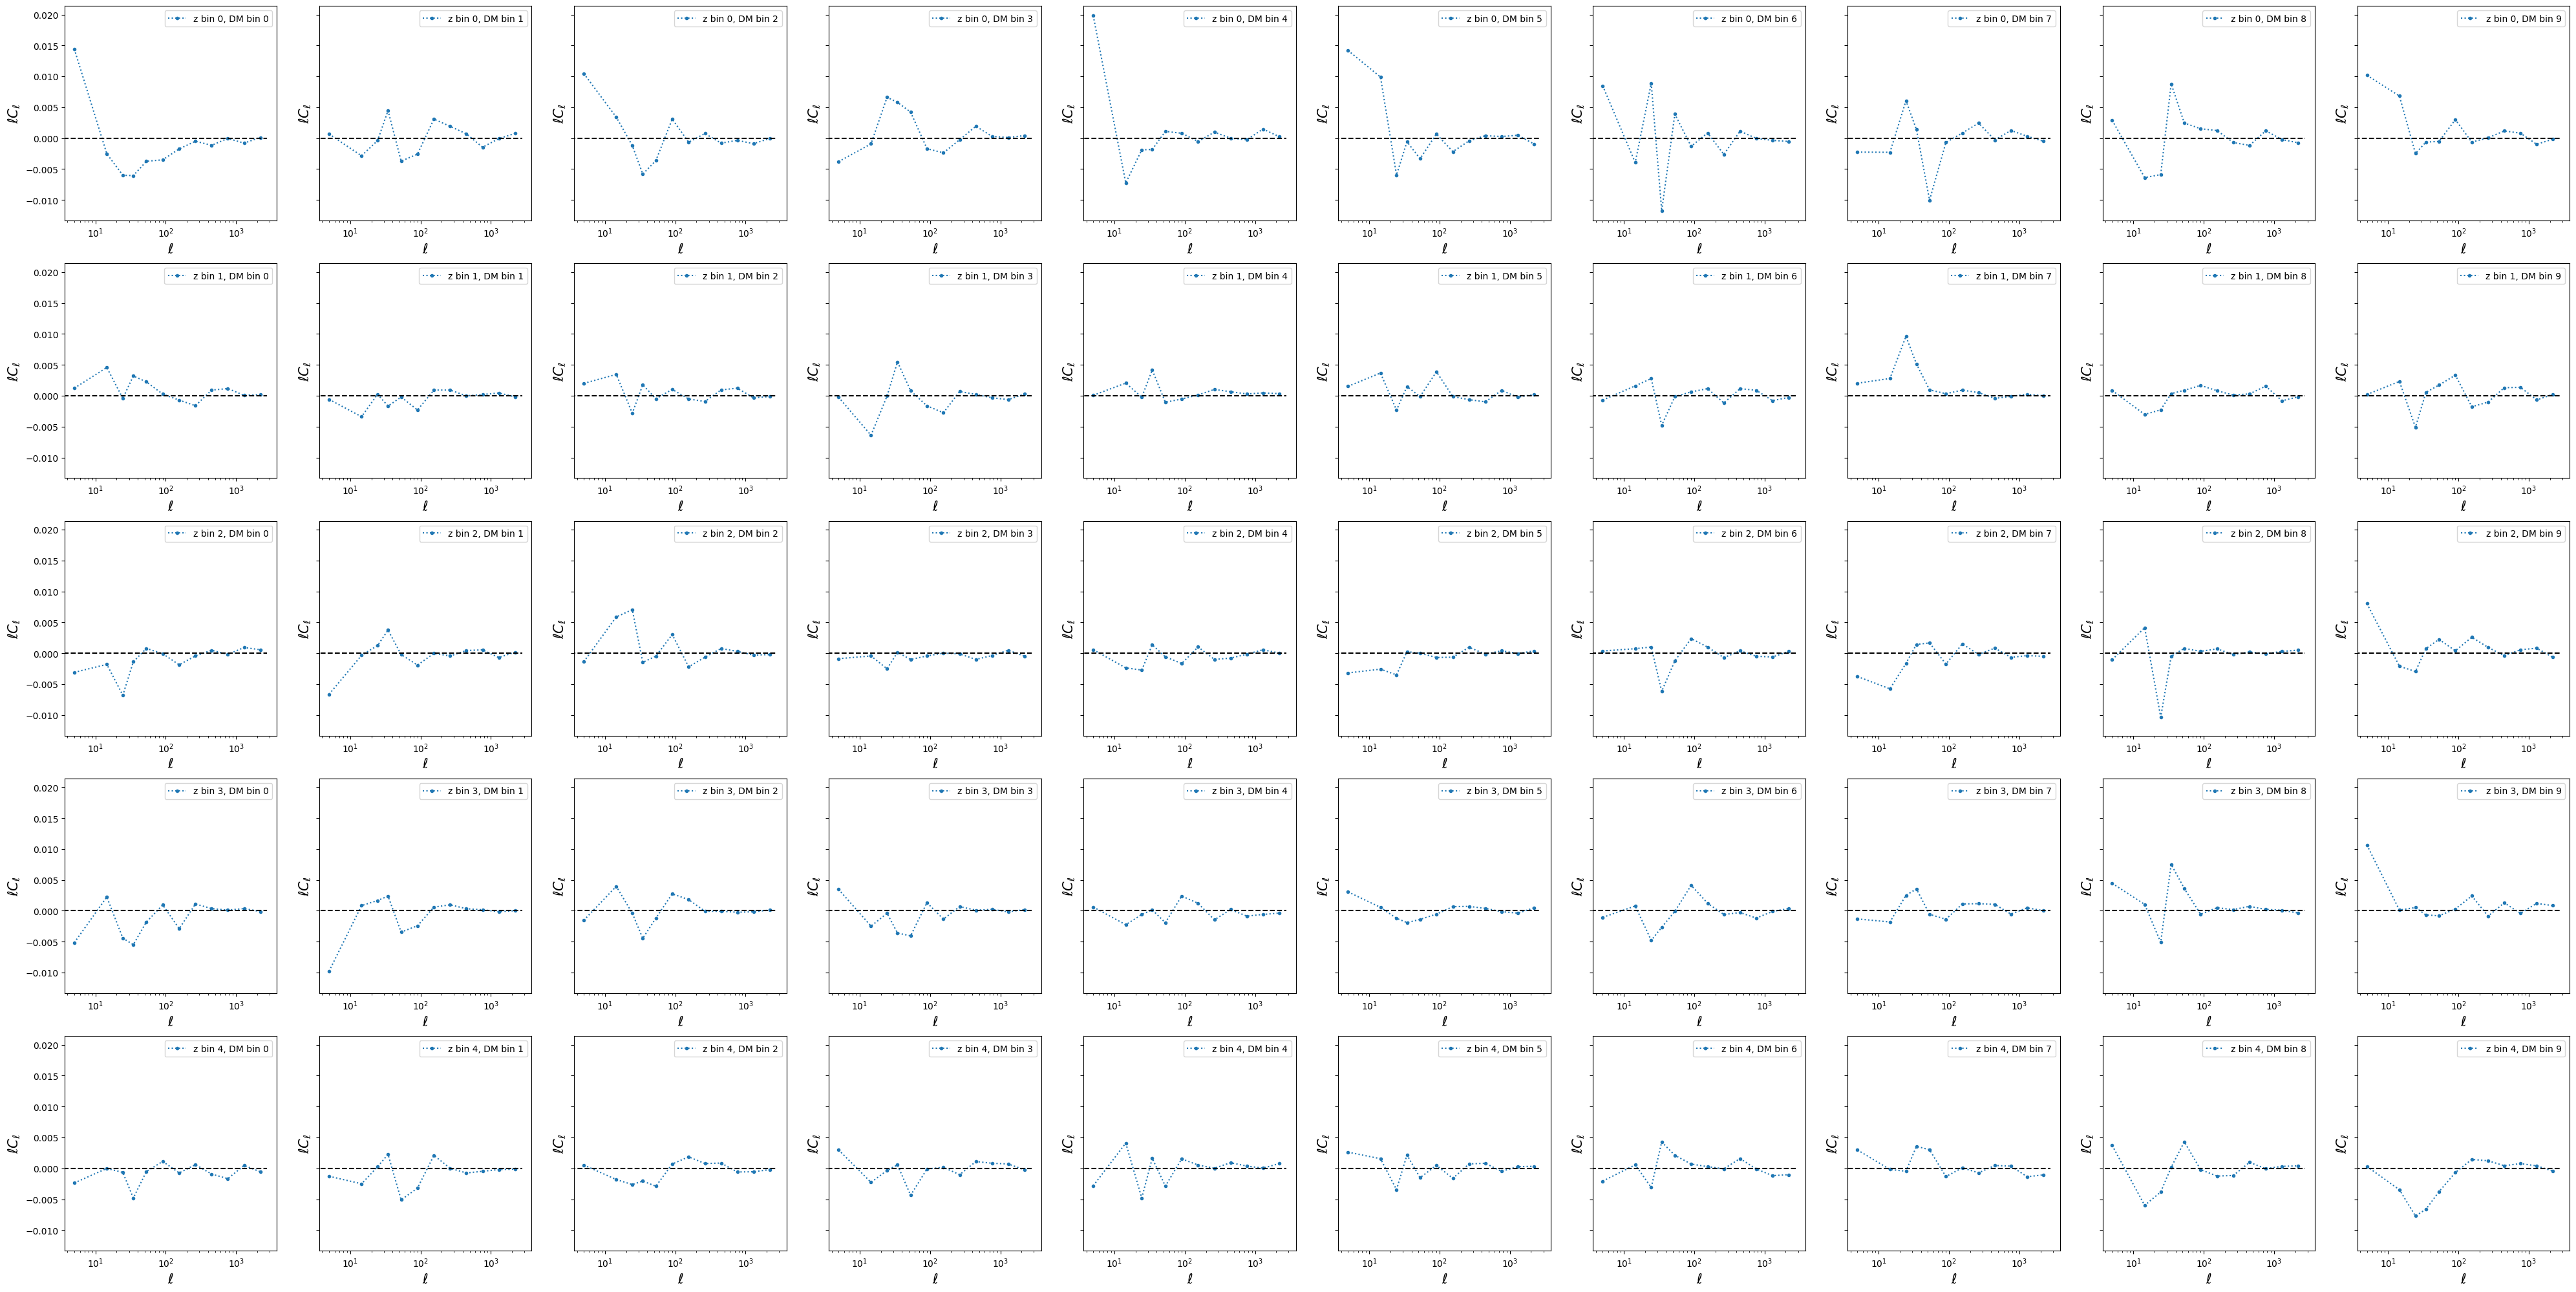

In [5]:
fg.plot_cl(figsize = (50, 25))

In [6]:
fg.null_test(10)

Estimating error bar for redshift bin 0 and DM bin 0.
0
Estimating error bar for redshift bin 0 and DM bin 1.
0
Estimating error bar for redshift bin 0 and DM bin 2.
0
Estimating error bar for redshift bin 0 and DM bin 3.
0
Estimating error bar for redshift bin 0 and DM bin 4.
0
Estimating error bar for redshift bin 0 and DM bin 5.
0
Estimating error bar for redshift bin 0 and DM bin 6.
0
Estimating error bar for redshift bin 0 and DM bin 7.
0
Estimating error bar for redshift bin 0 and DM bin 8.
0
Estimating error bar for redshift bin 0 and DM bin 9.
0
Estimating error bar for redshift bin 1 and DM bin 0.
0
Estimating error bar for redshift bin 1 and DM bin 1.
0
Estimating error bar for redshift bin 1 and DM bin 2.
0
Estimating error bar for redshift bin 1 and DM bin 3.
0
Estimating error bar for redshift bin 1 and DM bin 4.
0
Estimating error bar for redshift bin 1 and DM bin 5.
0
Estimating error bar for redshift bin 1 and DM bin 6.
0
Estimating error bar for redshift bin 1 and DM b

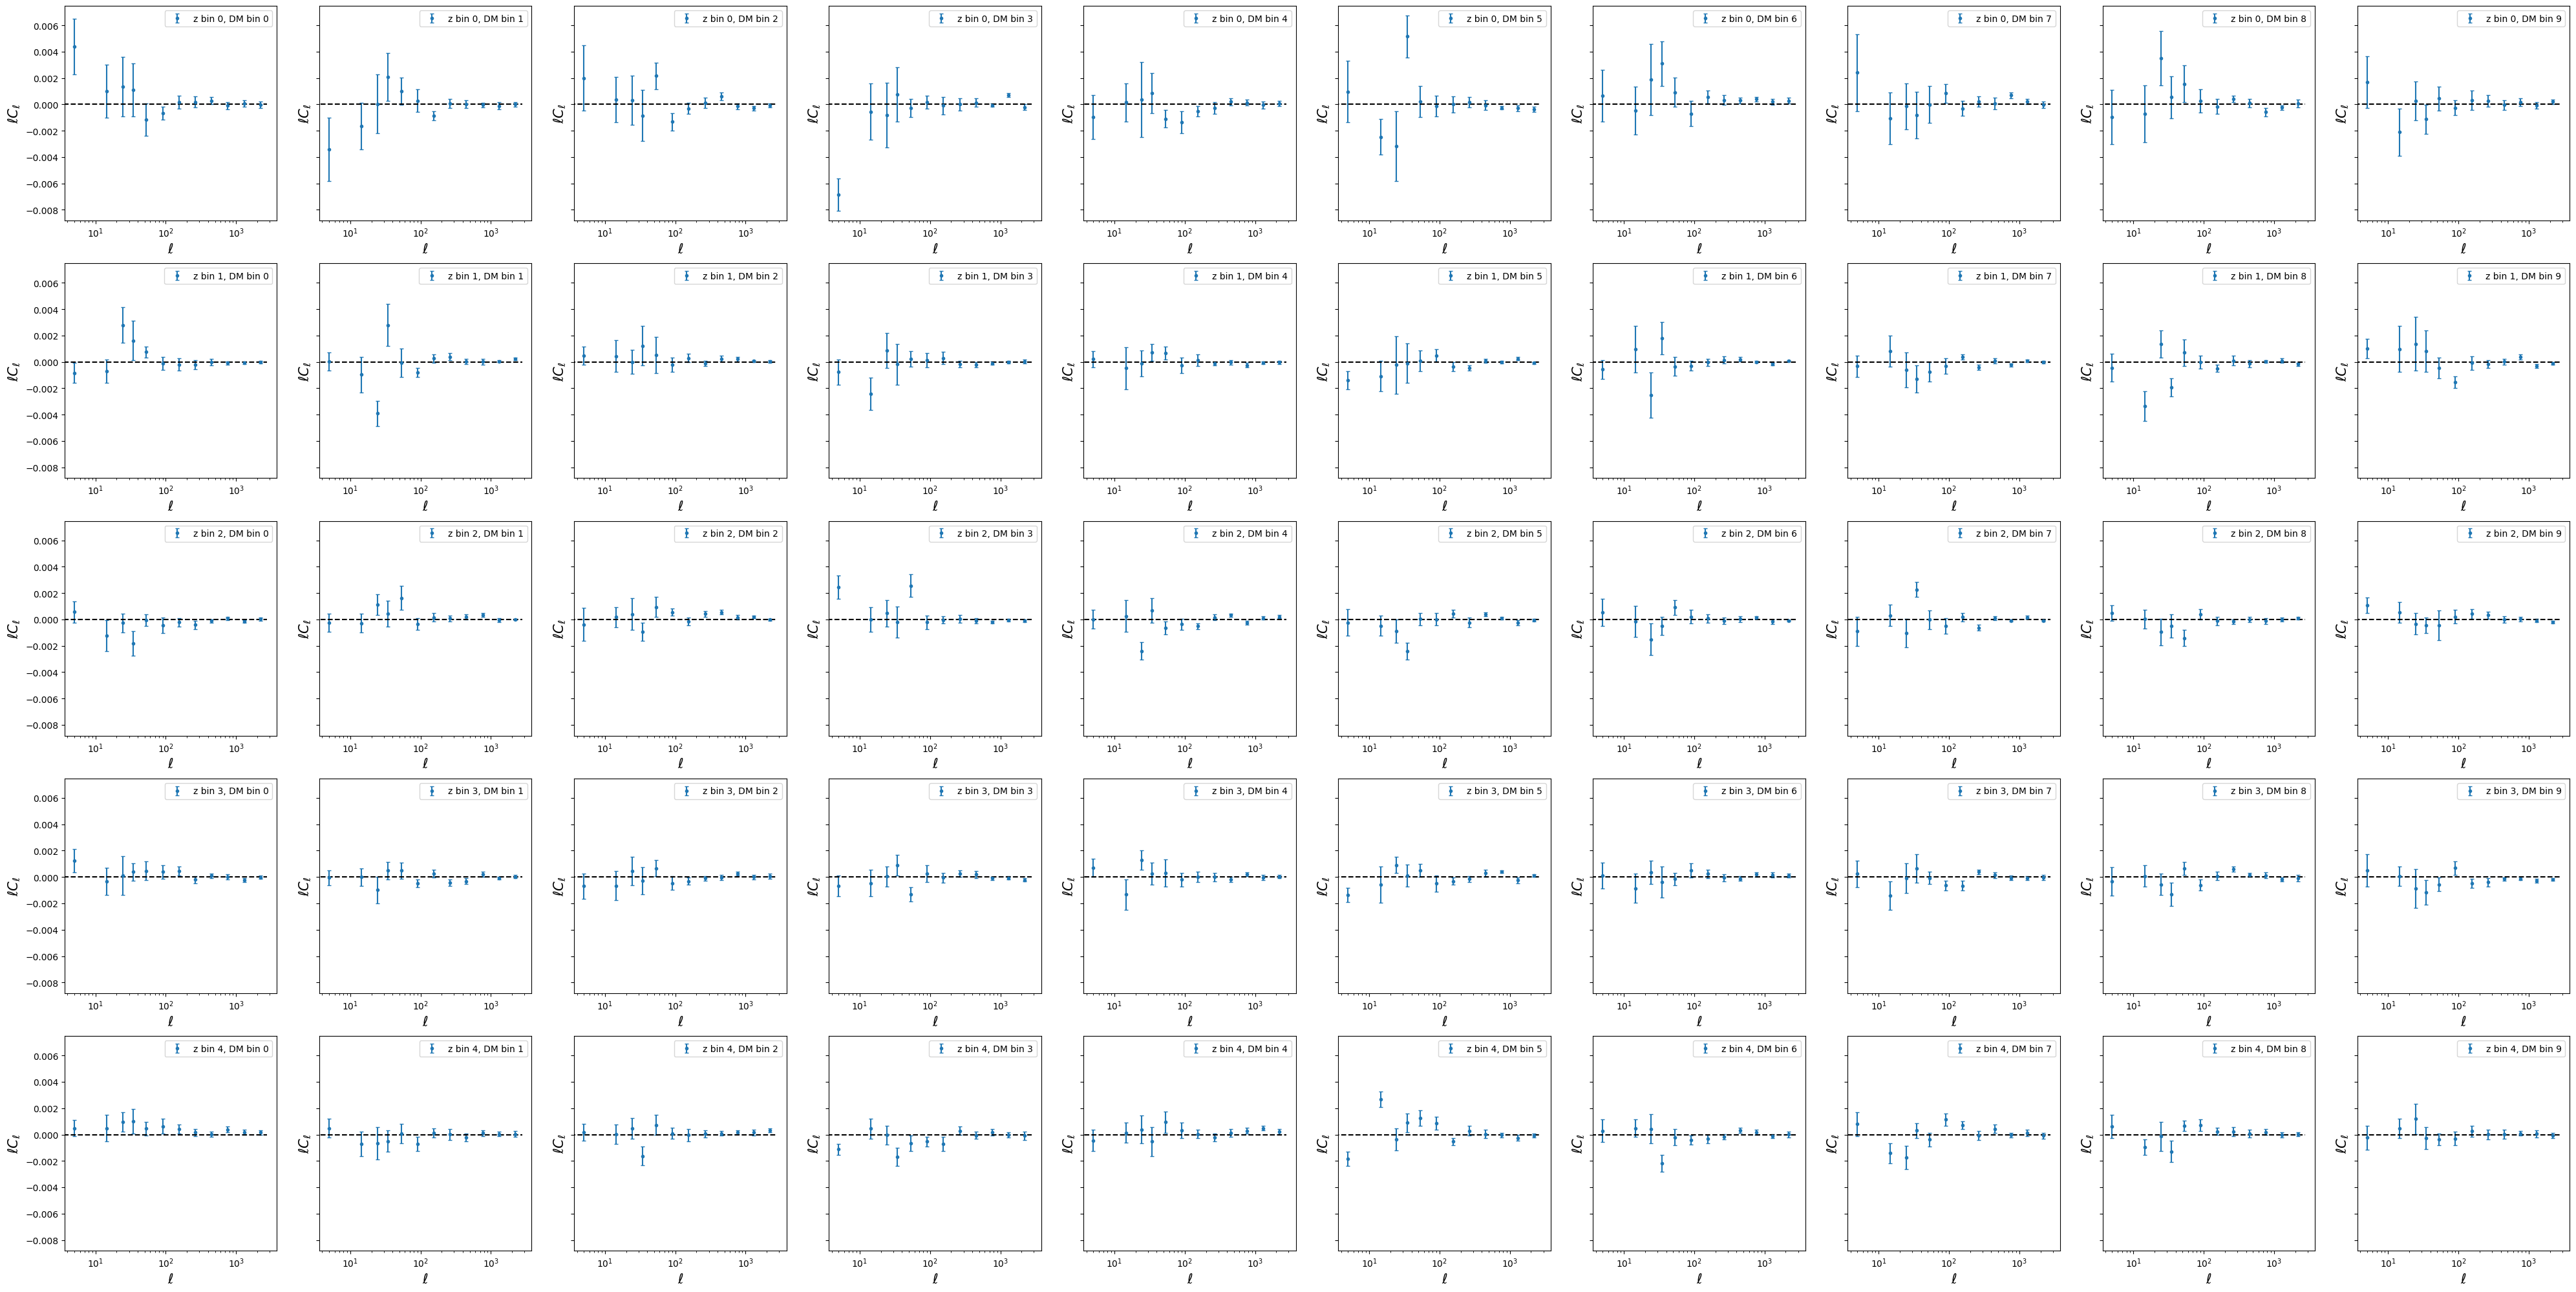

In [7]:
fg.plot_null_ps(figsize = (50, 25))

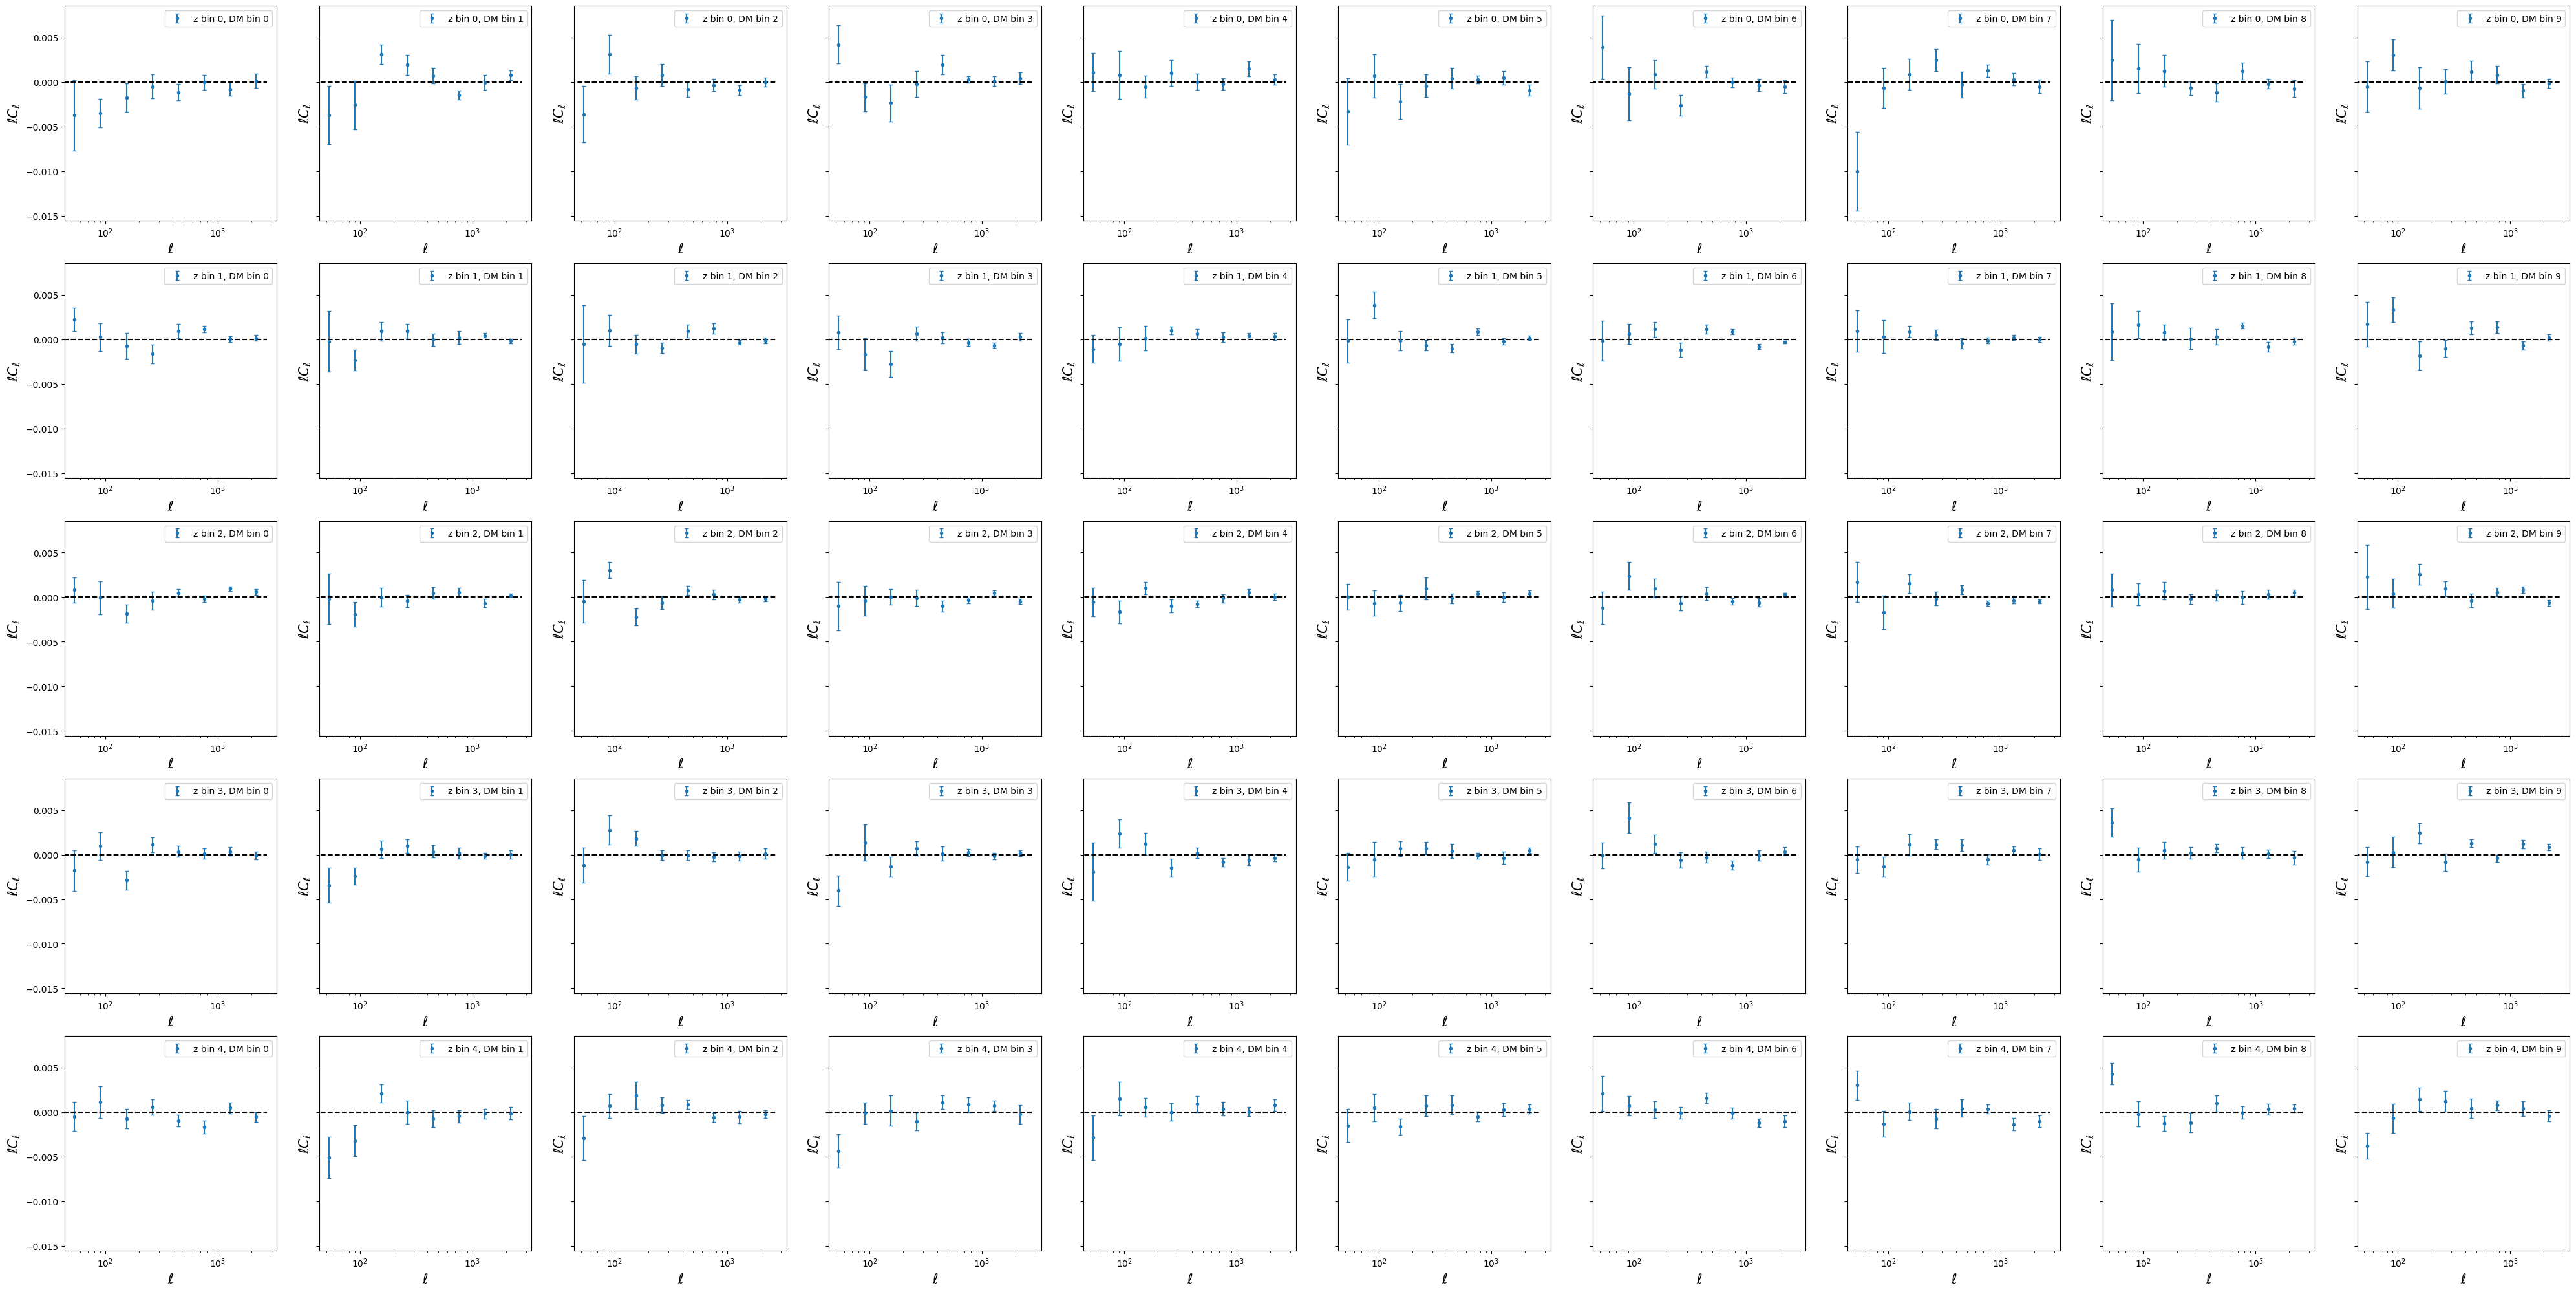

In [8]:
fg.plot_cl_err(exclude=True, figsize = (50, 25))

In [9]:
fg.null_test(100)

Estimating error bar for redshift bin 0 and DM bin 0.
0
Estimating error bar for redshift bin 0 and DM bin 1.
0
Estimating error bar for redshift bin 0 and DM bin 2.
0
Estimating error bar for redshift bin 0 and DM bin 3.
0
Estimating error bar for redshift bin 0 and DM bin 4.
0
Estimating error bar for redshift bin 0 and DM bin 5.
0
Estimating error bar for redshift bin 0 and DM bin 6.
0
Estimating error bar for redshift bin 0 and DM bin 7.
0
Estimating error bar for redshift bin 0 and DM bin 8.
0
Estimating error bar for redshift bin 0 and DM bin 9.
0
Estimating error bar for redshift bin 1 and DM bin 0.
0
Estimating error bar for redshift bin 1 and DM bin 1.
0
Estimating error bar for redshift bin 1 and DM bin 2.
0
Estimating error bar for redshift bin 1 and DM bin 3.
0
Estimating error bar for redshift bin 1 and DM bin 4.
0
Estimating error bar for redshift bin 1 and DM bin 5.
0
Estimating error bar for redshift bin 1 and DM bin 6.
0
Estimating error bar for redshift bin 1 and DM b

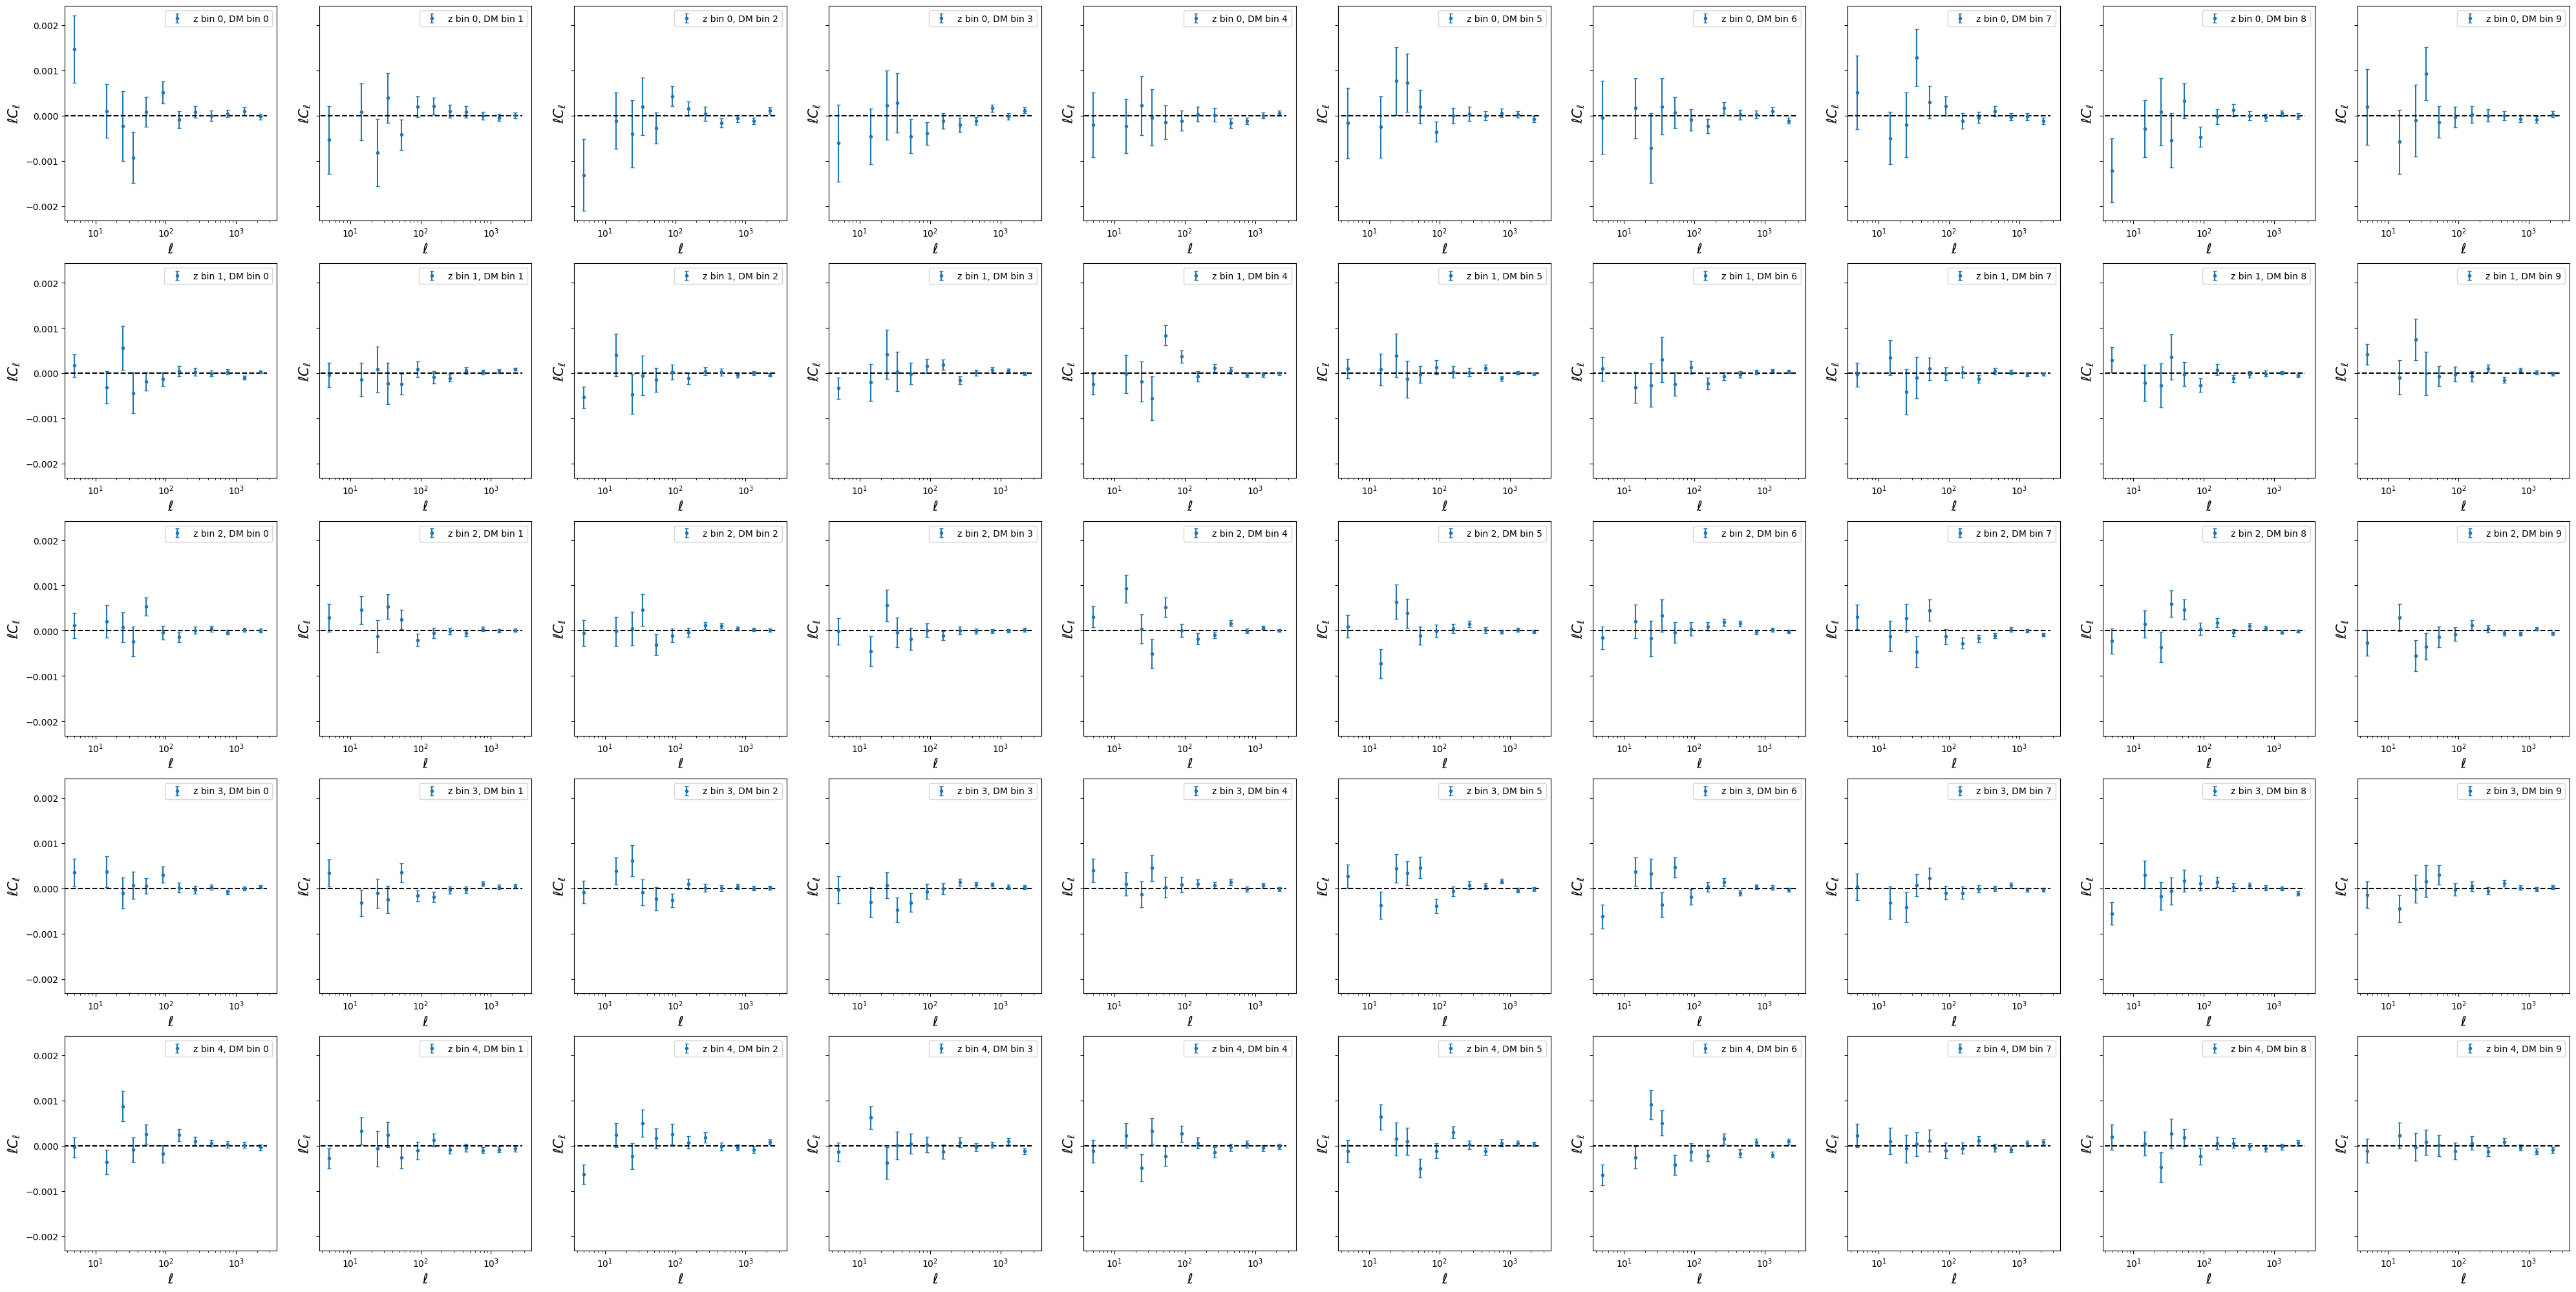

In [15]:
fg.plot_null_ps(figsize = (50, 25))

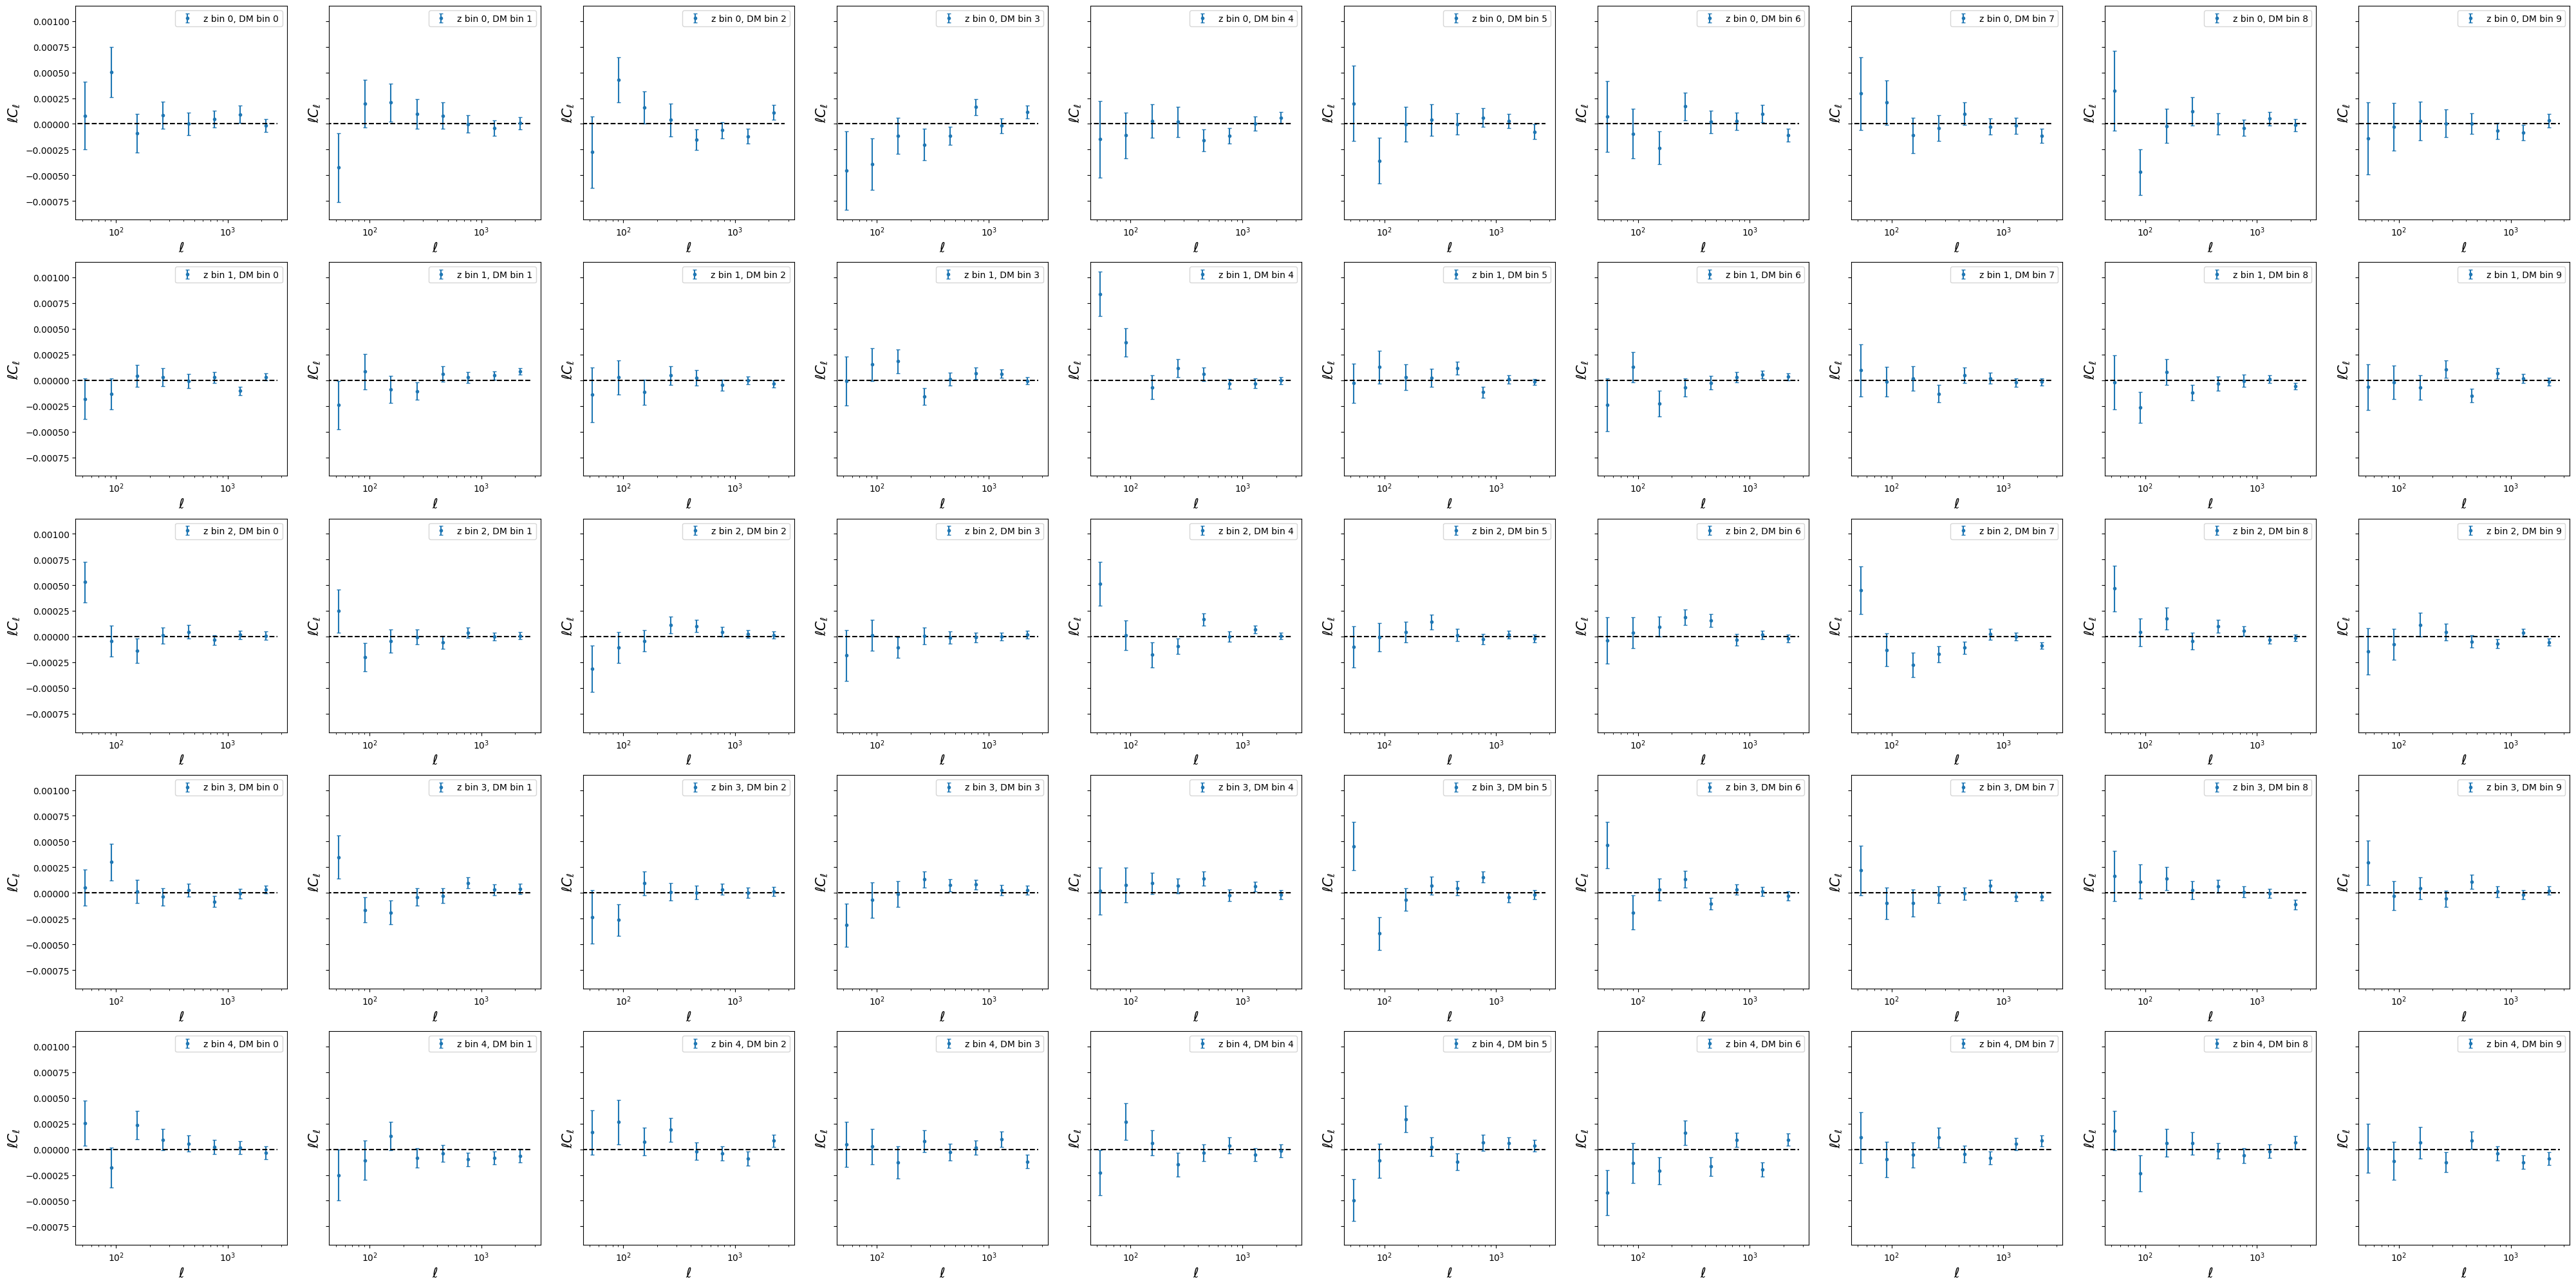

In [16]:
fg.plot_null_ps(exclude=True, figsize = (50, 25))

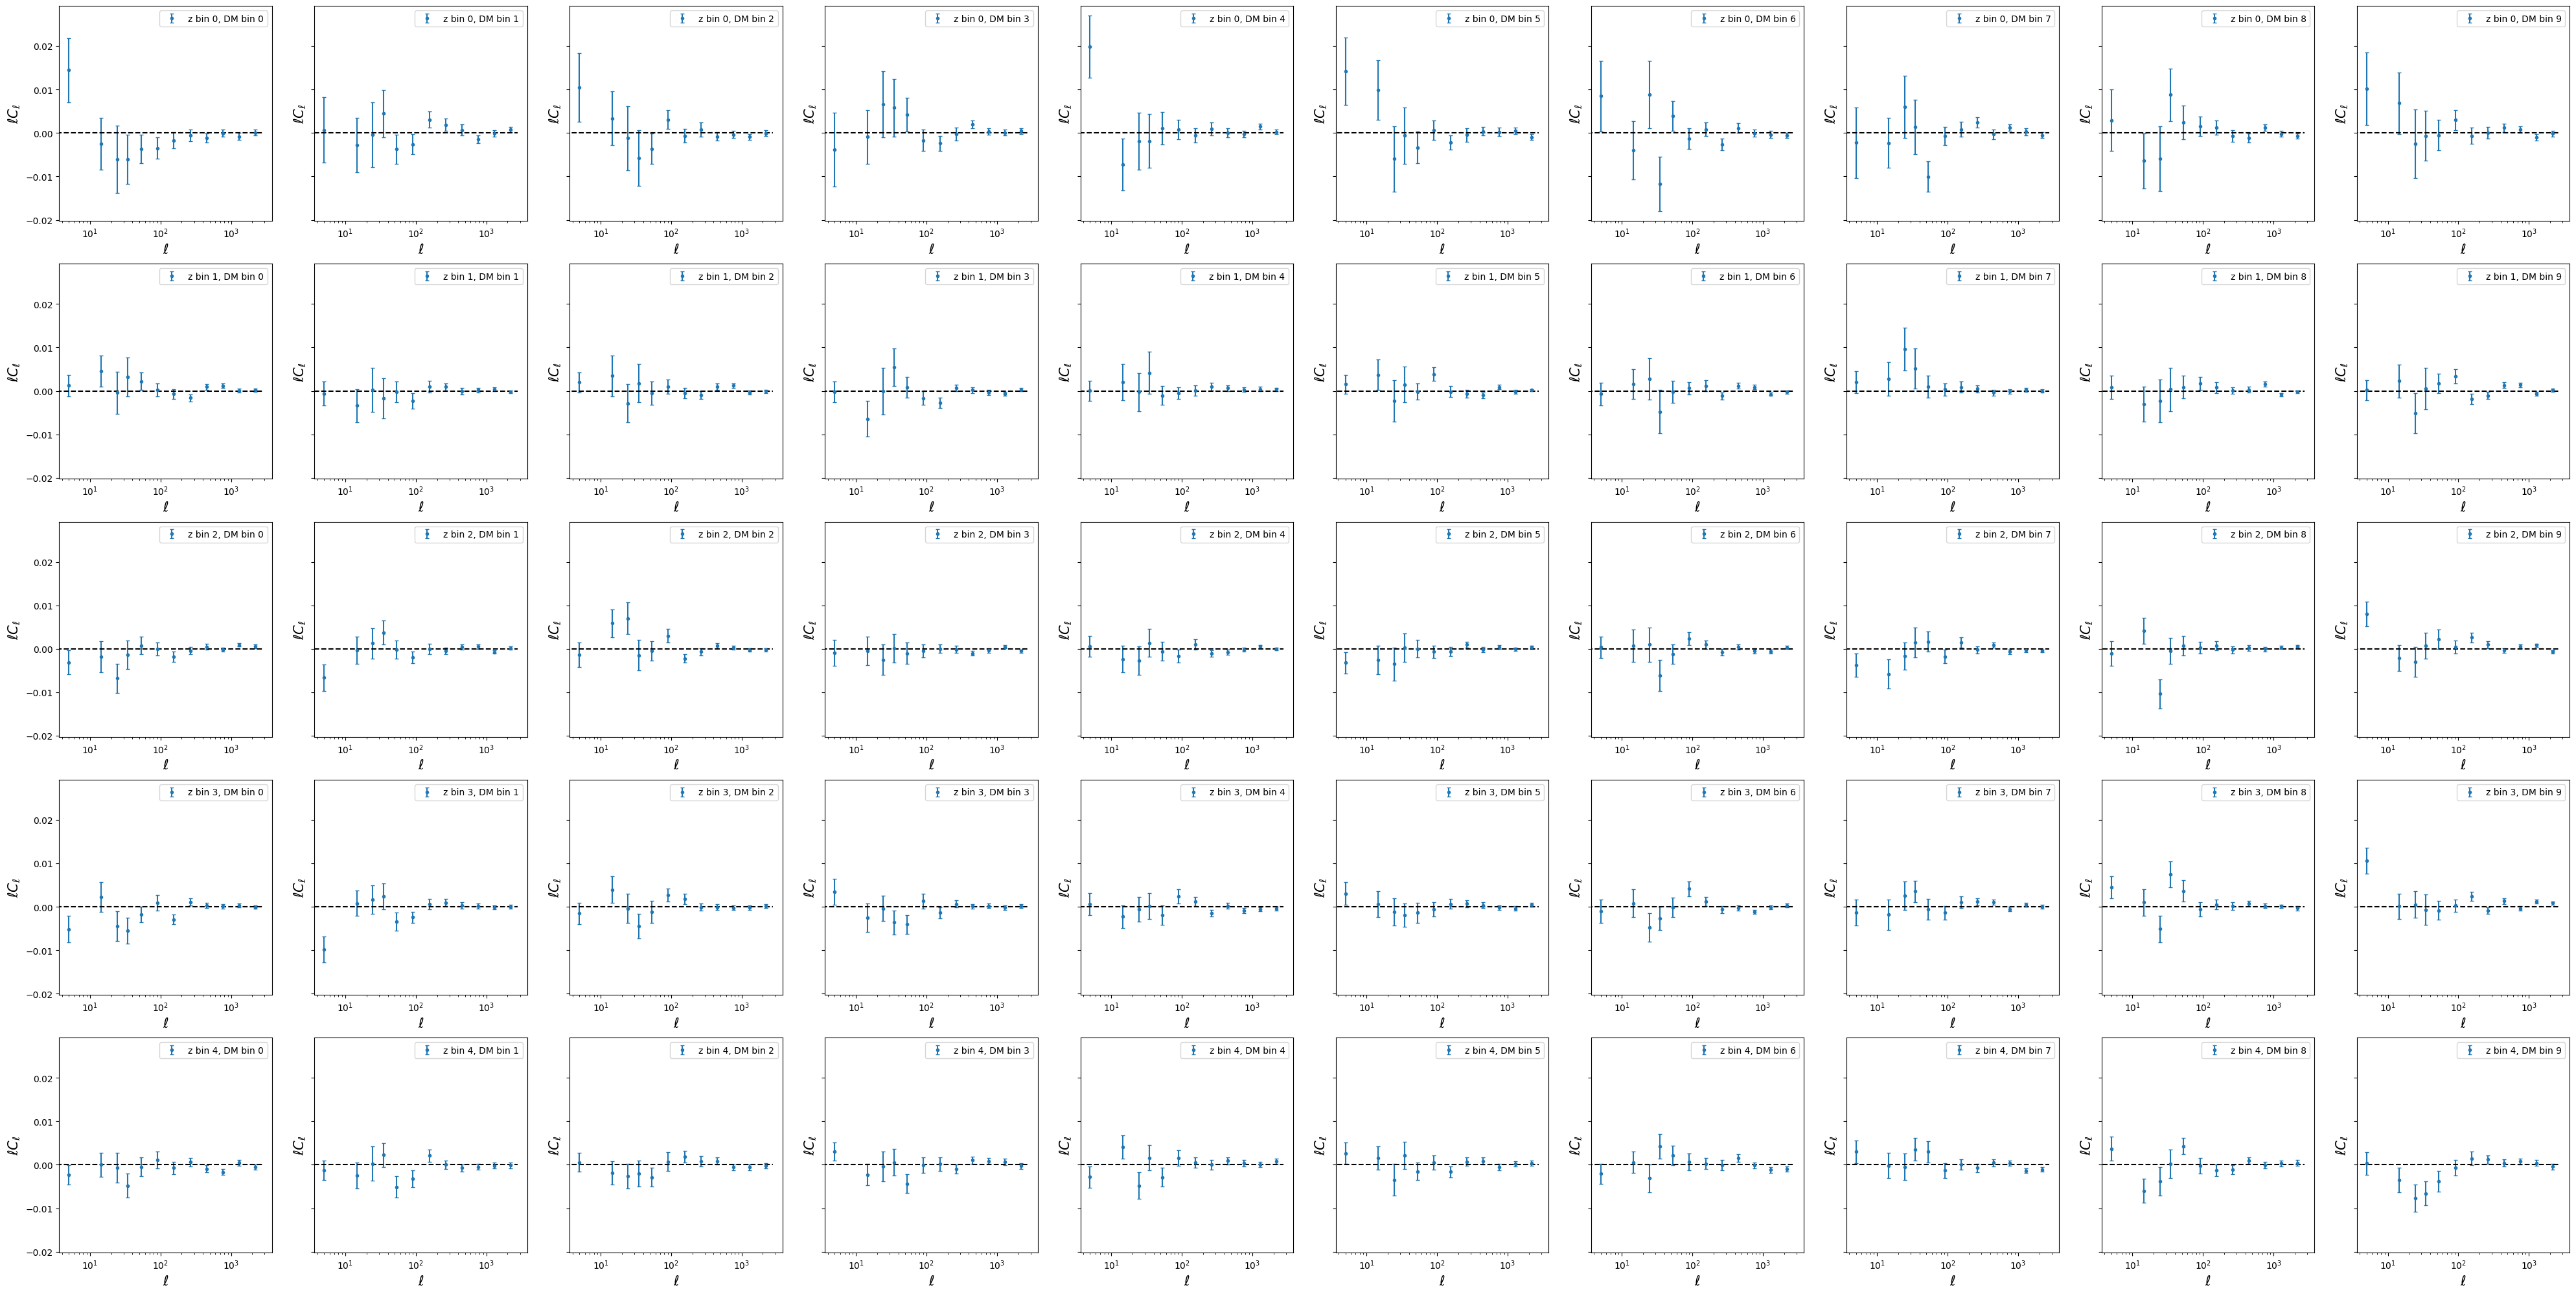

In [17]:
fg.plot_cl_err(figsize = (50, 25))

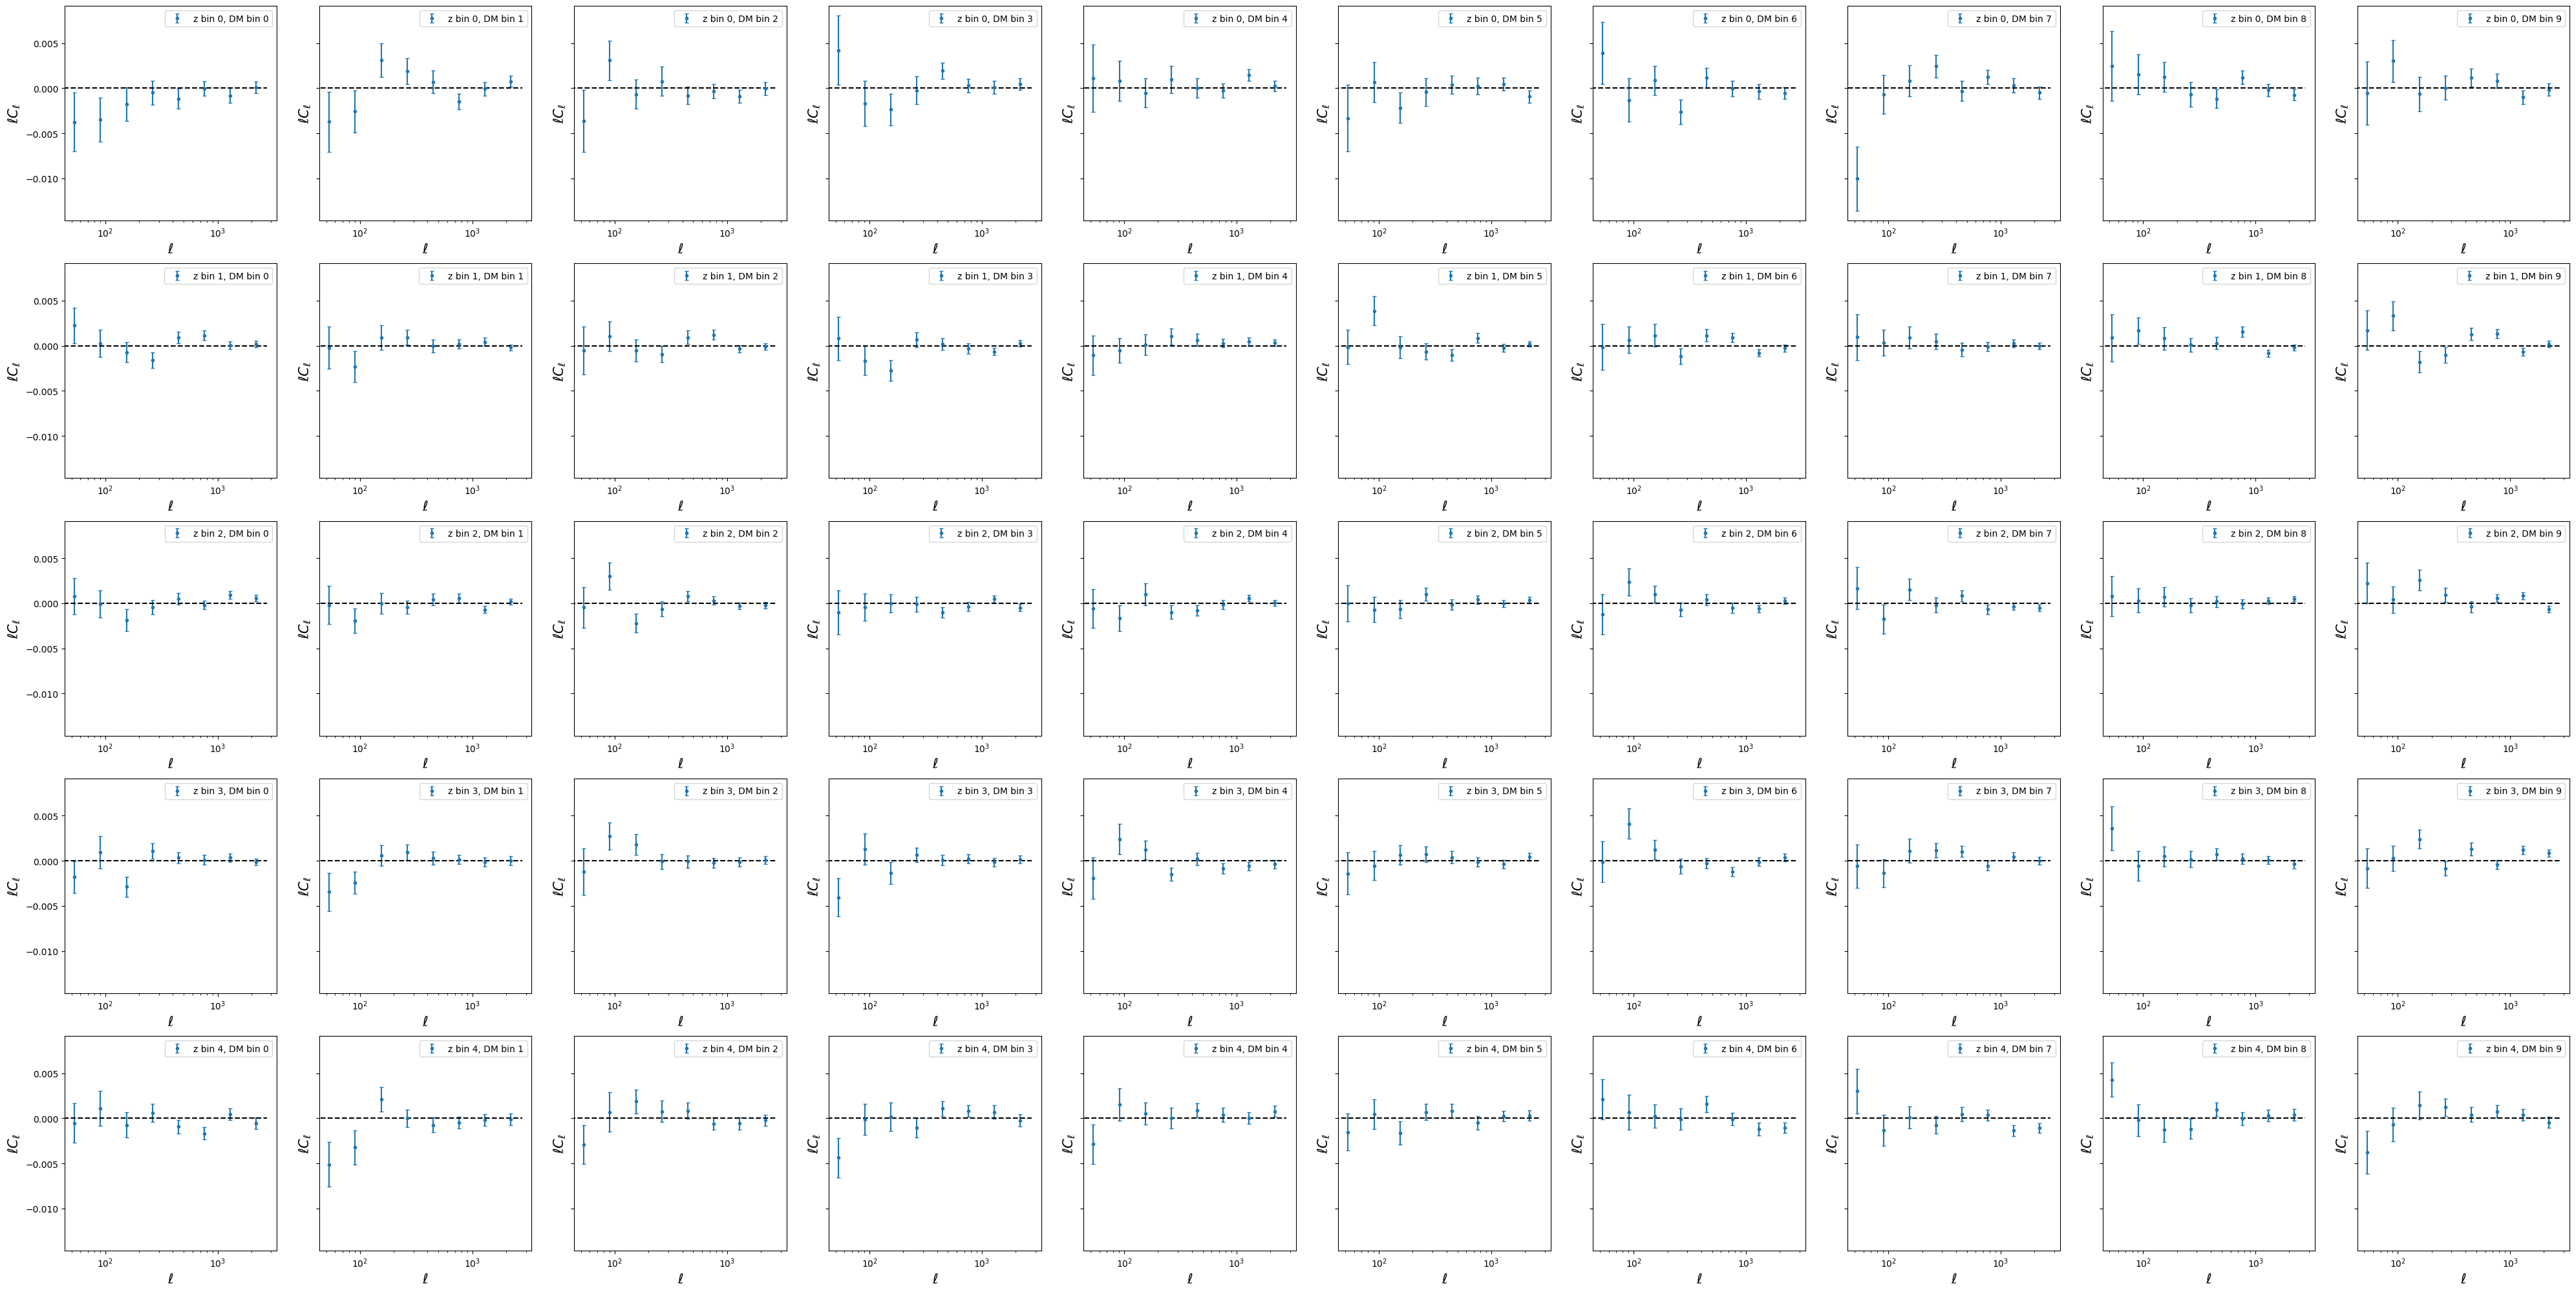

In [18]:
fg.plot_cl_err(exclude=True, figsize = (50, 25))

In [14]:
fg.save(notes = "second_try")

In [1]:
pwd

'/lustre06/project/6034496/hcwang96/frbxgal/CAT_2/first_correlation/dm_bins'